In [13]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
data = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data(data)

In [ ]:
# CatBoost
from catboost import CatBoostRegressor

# Avoiding any modification to original data sets since it uses column names and datatypes
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

#cat_features = X_train_cat.select_dtypes(include=["object", "category"]).columns.tolist()
cat_features = ["high_t_evt"]
#Tuning CatBoost in Optuna using the same method as XGBoost
def objective_cat(trial):
  CatBoost = CatBoostRegressor(
      iterations = 100,
      learning_rate = trial.suggest_float("learning_rate",0.01,0.1,log=True),
      depth = trial.suggest_int("depth",2,8),
      loss_function = "RMSE",
      eval_metric = "RMSE",
      random_seed = 42,
      verbose=False,
      allow_writing_files=False,
      posterior_sampling=True,
      )

  CatBoost.fit(
      X_train_cat, y_train, eval_set=(X_val_cat, y_val),cat_features=cat_features, use_best_model=True)
  predictions_cat = CatBoost.predict(X_val_cat)
  RMSE_cat = root_mean_squared_error(y_val, predictions_cat)
  return RMSE_cat
optimization_cat= optuna.create_study(direction="minimize") #minimizing the above parameters
optimization_cat.optimize(objective_cat, n_trials=30) #keeping trails low for runtime and to prevent over-fitting noise

optimal_params_cat = optimization_cat.best_params
print("Optimal Parameters Cat:", optimal_params_cat)

#Running CatBoost with the optimal parameters
CatBoost = CatBoostRegressor(
    iterations = 100,
    **optimal_params_cat,
    loss_function = "RMSE",
    eval_metric = "RMSE",
    random_seed = 42,
    verbose=False,
    allow_writing_files=False
    )

CatBoost.fit(
    X_train_cat, y_train, eval_set=(X_val_cat, y_val),cat_features=cat_features, use_best_model=True)

# Calculating the multiplicative error
CatBoost_Prediction = CatBoost.predict(X_test_cat)
CatBoost_RMSE = root_mean_squared_error(y_test, CatBoost_Prediction)
CatBoost_Error = CatBoost_RMSE
print("CatBoost Error:", CatBoost_Error)

[I 2026-01-24 11:10:06,761] A new study created in memory with name: no-name-21f13ca8-1e9e-455e-a1fe-e443a238c724
[I 2026-01-24 11:10:06,925] Trial 0 finished with value: 1926.2751262700995 and parameters: {'learning_rate': 0.022148710301714926, 'depth': 8}. Best is trial 0 with value: 1926.2751262700995.
[I 2026-01-24 11:10:07,025] Trial 1 finished with value: 1926.0575204840638 and parameters: {'learning_rate': 0.014278289726828238, 'depth': 7}. Best is trial 1 with value: 1926.0575204840638.
[I 2026-01-24 11:10:07,126] Trial 2 finished with value: 1925.6888649787206 and parameters: {'learning_rate': 0.013507250803475979, 'depth': 5}. Best is trial 2 with value: 1925.6888649787206.
[I 2026-01-24 11:10:07,226] Trial 3 finished with value: 1925.362736415022 and parameters: {'learning_rate': 0.024877255158566307, 'depth': 2}. Best is trial 3 with value: 1925.362736415022.
[I 2026-01-24 11:10:07,334] Trial 4 finished with value: 1927.1103327222668 and parameters: {'learning_rate': 0.0317

Optimal Parameters Cat: {'learning_rate': 0.03441250436004667, 'depth': 5}
CatBoost Error: 2907.68049507808


CatBoost Error: 2907.68049507808
Average Error per Record in seconds for Cat: 605.1798452679726
Sample0: True = 665.00s, Predicted = 1132.62s, Error=467.62s
Sample1: True = 897.75s, Predicted = 1123.62s, Error=225.87s
Sample2: True = 1377.25s, Predicted = 1127.18s, Error=250.07s
Sample3: True = 1545.00s, Predicted = 1127.18s, Error=417.82s
Sample4: True = 1230.00s, Predicted = 1132.62s, Error=97.38s
Sample5: True = 803.75s, Predicted = 1127.18s, Error=323.43s
Sample6: True = 790.00s, Predicted = 1123.62s, Error=333.62s
Sample7: True = 1196.25s, Predicted = 1123.62s, Error=72.63s
Sample8: True = 920.00s, Predicted = 1127.18s, Error=207.18s
Sample9: True = 715.00s, Predicted = 1123.62s, Error=408.62s
Sample10: True = 1223.75s, Predicted = 1123.62s, Error=100.13s
Sample11: True = 1396.25s, Predicted = 1127.18s, Error=269.07s
Sample12: True = 1448.75s, Predicted = 1126.45s, Error=322.30s
Sample13: True = 1446.25s, Predicted = 1130.06s, Error=316.19s
Sample14: True = 1505.00s, Predicted = 1

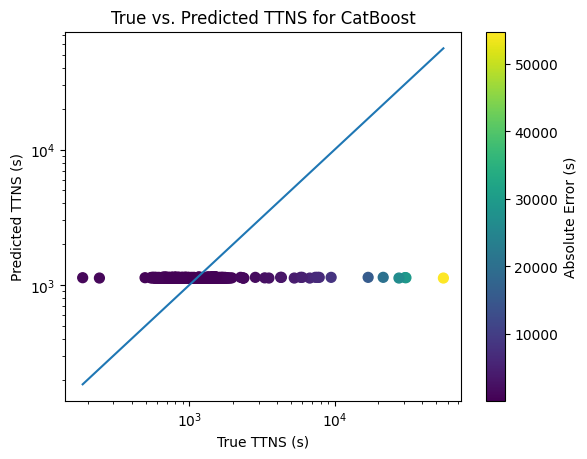

In [16]:
#Calculating multiplicative error for CatBoost
CatBoost_Prediction = CatBoost.predict(X_test_cat)
CatBoost_RMSE = root_mean_squared_error(y_test, CatBoost_Prediction)
CatBoost_Error = CatBoost_RMSE
print("CatBoost Error:", CatBoost_Error)

y_test_secs = y_test
Cat_pred_secs = CatBoost_Prediction

absolute_error_secs_Cat = np.abs(Cat_pred_secs - y_test_secs)

#absoulte_error_cat = np.abs(10**CatBoost_Prediction - y_test)
MAE_seconds = np.mean(absolute_error_secs_Cat)
print("Average Error per Record in seconds for Cat:", MAE_seconds)


#Calculating true value, predicted, and average error in terms of seconds for each event
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, Cat_pred_secs, absolute_error_secs_Cat)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, Cat_pred_secs, c=absolute_error_secs_Cat, cmap='viridis', s=50)
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for CatBoost")
plt.xscale('log')
plt.yscale('log')
plt.show()